In [1]:
# Import modules used in the POD
import os
import matplotlib

matplotlib.use('Agg')  # non-X windows backend

import matplotlib.pyplot as plt
import numpy as np
import intake
import sys
import yaml

In [9]:
# Receive a dictionary of case information from the framework
print("reading case_info")
#case_env_file = os.environ["case_env_file"]
#case_env_file = os.environ['/glade/work/jshin/mdtf/wkdir/MDTF_output.v135/WBC_var/case_info.yml']
case_env_file = '/glade/work/jshin/mdtf/wkdir/MDTF_output.v135/WBC_var/case_info.yml'
assert os.path.isfile(case_env_file), f"case environment file not found"
with open(case_env_file, 'r') as stream:
    try:
        case_info = yaml.safe_load(stream)
    except yaml.YAMLError as exc:
        print(exc)

cat_def_file = case_info['CATALOG_FILE']
case_list = case_info['CASE_LIST']
# all cases share variable names and dimension coords in this example, so just get first result for each
tas_var = [case['zos_var'] for case in case_list.values()][0]
time_coord = [case['time_coord'] for case in case_list.values()][0]
lat_coord = [case['lat_coord'] for case in case_list.values()][0]
lon_coord = [case['lon_coord'] for case in case_list.values()][0]

reading case_info


In [10]:
# open the csv file using information provided by the catalog definition file
cat = intake.open_esm_datastore(cat_def_file)
cat

,unique
Conventions,0
activity_id,1
creation_date,0
data_specs_version,0
experiment,1
experiment_id,1
forcing_index,0
frequency,1
further_info_url,0
grid,2


In [11]:
cat.df

,Conventions,activity_id,creation_date,data_specs_version,experiment,experiment_id,forcing_index,frequency,further_info_url,grid,...,table_id,tracking_id,variable_id,member_id,chunk_freq,path,standard_name,time_range,variant_label,project_id
0,NaN,HighResMIP,NaN,NaN,coupled historical 1950-2014,hist-1950,NaN,mon,NaN,ORCA025,...,Omon,NaN,zos,r1i1p2f1,NaN,/glade/work/jshin/mdtf/wkdir/MDTF_output.v135/...,sea_surface_height_above_geoid,19500116:12:00:00-20141216:12:00:00,r1i1p2f1,cmip
1,NaN,HighResMIP,NaN,NaN,coupled historical 1950-2014,hist-1950,NaN,mon,NaN,ORCA05,...,Omon,NaN,zos,r1i1p2f1,NaN,/glade/work/jshin/mdtf/wkdir/MDTF_output.v135/...,sea_surface_height_above_geoid,19500116:12:00:00-20141216:12:00:00,r1i1p2f1,cmip


In [13]:
tas_subset = cat.search(variable_id=tas_var, frequency="mon")
tas_subset 

,unique
Conventions,0
activity_id,1
creation_date,0
data_specs_version,0
experiment,1
experiment_id,1
forcing_index,0
frequency,1
further_info_url,0
grid,2


In [14]:
tas_subset.df

,Conventions,activity_id,creation_date,data_specs_version,experiment,experiment_id,forcing_index,frequency,further_info_url,grid,...,table_id,tracking_id,variable_id,member_id,chunk_freq,path,standard_name,time_range,variant_label,project_id
0,NaN,HighResMIP,NaN,NaN,coupled historical 1950-2014,hist-1950,NaN,mon,NaN,ORCA025,...,Omon,NaN,zos,r1i1p2f1,NaN,/glade/work/jshin/mdtf/wkdir/MDTF_output.v135/...,sea_surface_height_above_geoid,19500116:12:00:00-20141216:12:00:00,r1i1p2f1,cmip
1,NaN,HighResMIP,NaN,NaN,coupled historical 1950-2014,hist-1950,NaN,mon,NaN,ORCA05,...,Omon,NaN,zos,r1i1p2f1,NaN,/glade/work/jshin/mdtf/wkdir/MDTF_output.v135/...,sea_surface_height_above_geoid,19500116:12:00:00-20141216:12:00:00,r1i1p2f1,cmip


In [20]:
# convert tas_subset catalog to an xarray dataset dict
tas_dict = tas_subset.to_dataset_dict(
    progressbar=False,
    aggregate=False,
    xarray_open_kwargs={"decode_times": True, "use_cftime": True}
)

# renaming keys in tas_dict to that found in case_list
tas_keys = list(tas_dict) 
case_keys = list(case_list)
for i in range(len(tas_keys)):
    tas_dict[case_keys[i]] = tas_dict.pop(tas_keys[i])

ESMDataSourceError: Failed to load dataset with key='HighResMIP.coupled historical 1950-2014.hist-1950.mon.ORCA025.gn.EC-Earth-Consortium.25 km.model-output.ocean.EC-Earth3P-HR.AOGCM.none.none.Omon.zos.r1i1p2f1./glade/work/jshin/mdtf/wkdir/MDTF_output.v135/MDTF_EC-Earth3P-HR_19500101_20141230/mon/EC-Earth3P-HR.zos.mon.nc.sea_surface_height_above_geoid.19500116:12:00:00-20141216:12:00:00.r1i1p2f1.cmip'
                 You can use `cat['HighResMIP.coupled historical 1950-2014.hist-1950.mon.ORCA025.gn.EC-Earth-Consortium.25 km.model-output.ocean.EC-Earth3P-HR.AOGCM.none.none.Omon.zos.r1i1p2f1./glade/work/jshin/mdtf/wkdir/MDTF_output.v135/MDTF_EC-Earth3P-HR_19500101_20141230/mon/EC-Earth3P-HR.zos.mon.nc.sea_surface_height_above_geoid.19500116:12:00:00-20141216:12:00:00.r1i1p2f1.cmip'].df` to inspect the assets/files for this key.
                 

In [16]:
# Part 2: Do some calculations (time and zonal means)
# ---------------------------------------------------

tas_arrays = {}

# Loop over cases
for k, v in tas_dict.items():
    # load the tas data for case k
    print("case:",k)
    arr = tas_dict[k][tas_var]

    # take the time mean
    arr = arr.mean(dim=tas_dict[k][time_coord].name)

    # this block shuffles the data to make this single case look more
    # interesting.  ** DELETE THIS ** once we test with real data

    arr.load()
    values = arr.to_masked_array().flatten()
    np.random.shuffle(values)
    values = values.reshape(arr.shape)
    arr.values = values

    # convert to anomalies
    arr = arr - arr.mean()

    # take the zonal mean
    arr = arr.mean(dim=tas_dict[k][lon_coord].name)

    tas_arrays[k] = arr

case: EC-Earth3P
case: EC-Earth3P-HR


In [17]:
# Part 3: Make a plot that contains results from each case
# --------------------------------------------------------
print("Let's plot!")
print("--------------------------------------")

# set up the figure
fig = plt.figure(figsize=(12, 4))
ax = plt.subplot(1, 1, 1)

# loop over cases
for k, v in tas_arrays.items():
    v.plot(ax=ax, label=k)

# add legend
plt.legend()

# add title
plt.title("Zonal Mean Surface Air Temperature Anomaly")

Let's plot!
--------------------------------------


Text(0.5, 1.0, 'Zonal Mean Surface Air Temperature Anomaly')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


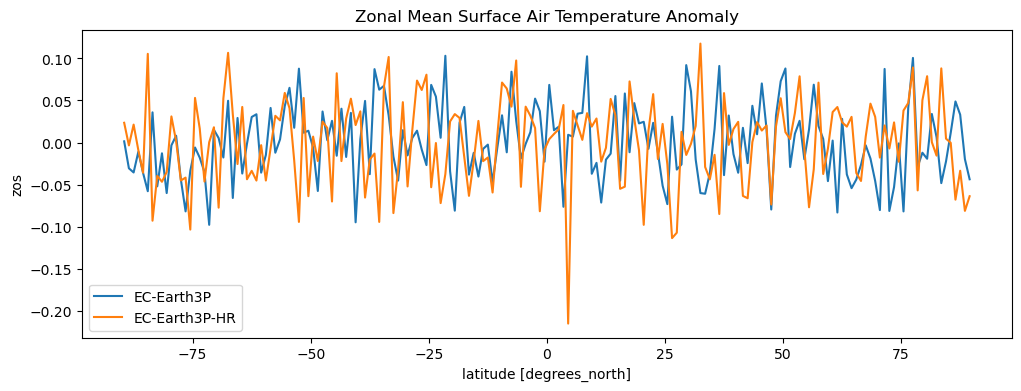

In [19]:
%matplotlib inline
# save the plot in the right location
#work_dir = os.environ["WORK_DIR"]
work_dir = '/glade/work/jshin/mdtf/wkdir/MDTF_output.v135/WBC_var/'
assert os.path.isdir(f"{work_dir}/model/PS"), f'Assertion error: {work_dir}/model/PS not found'

plt.savefig(f"{work_dir}/model/PS/example_multicase_plot.eps", bbox_inches="tight")
plt.show()

In [ ]:
# Part 4: running an external script
# the use of external python scripts can help prevent bloat in the notebook
# here, we show how this can be done
#sys.path.append(os.environ["POD_HOME"])

import script
script.HelloWorld()

In [ ]:
# Part 5: Close the catalog files and
# release variable dict reference for garbage collection
# ------------------------------------------------------
cat.close()
tas_dict = None

# Part 6: Confirm POD executed successfully
# ----------------------------------------
print("Last log message by example_multicase POD: finished successfully!")